Do Popes act as bridges between historical communities?

In [2]:
# Add imports
import urllib
import networkx as nx
import io
import json
import re
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import random
import pandas as pd
import seaborn as sns
import matplotlib.colors as mcolors
import numpy as np
from itertools import islice
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import numpy as np
import urllib.request
import json
import os
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
from wordcloud import *

In [3]:
# Load the network
url = "https://raw.githubusercontent.com/denisababeii/socialgraphs_project/refs/heads/main/celebrities_clean_without_content.graphml"
    
try:
    with urllib.request.urlopen(url) as response:
        data = response.read()
        
    network = nx.read_graphml(io.BytesIO(data))
    print(f"✓ Network loaded successfully!")
    print(f"  Nodes: {network.number_of_nodes()}")
    print(f"  Edges: {network.number_of_edges()}")
        
except Exception as e:
    print(f"✗ Error loading network: {str(e)}")
    network = None

✓ Network loaded successfully!
  Nodes: 11286
  Edges: 125705


In [4]:
era_order_display = [
    'Before Christ (< 30)',
    'Classical Era (30-476)',
    'Middle Ages (476-1450)',
    'Early Modern (1450-1760)',
    'Industrial Era (1760-1840)',
    'Wartime (1840-1945)',
    'Post-War (1945-2025)'
]

def get_era(birth_year):
    """Determine which era a birth year belongs to"""
    if birth_year is None:
        return 'Unknown'
    
    try:
        year = int(birth_year)
    except (ValueError, TypeError):
        return 'Unknown'
    
    if year < 30:
        return 'Before Christ (< 30)'
    elif 30 <= year < 476:
        return 'Classical Era (30-476)'
    elif 476 <= year < 1450:
        return 'Middle Ages (476-1450)'
    elif 1450 <= year < 1760:
        return 'Early Modern (1450-1760)'
    elif 1760 <= year < 1840:
        return 'Industrial Era (1760-1840)'
    elif 1840 <= year < 1945:
        return 'Wartime (1840-1945)'
    elif 1945 <= year <= 2025:
        return 'Post-War (1945-2025)'
    else:
        return 'Unknown'

ANALYZING: Do Popes Act as Bridges Between Historical Communities?

Found 266 Pope nodes

Network without Popes:
  Nodes: 11020
  Edges: 101115
  Connected components: 236

Communities detected (without Popes): 289

Top 5 Communities (without Popes):

  Community 1: 4131 members
    Top eras: [('Wartime (1840-1945)', 1702), ('Early Modern (1450-1760)', 778), ('Industrial Era (1760-1840)', 669)]
    Top occupations: [('POLITICIAN', 1037), ('WRITER', 768), ('PHILOSOPHER', 266)]
    Top cities: [('OTHER', 233), ('PARIS', 166), ('LONDON', 89)]

  Community 2: 3349 members
    Top eras: [('Post-War (1945-2025)', 2005), ('Wartime (1840-1945)', 1331), ('Middle Ages (476-1450)', 6)]
    Top occupations: [('ACTOR', 1120), ('POLITICIAN', 757), ('SINGER', 385)]
    Top cities: [('NEW YORK', 238), ('LOS ANGELES', 160), ('CHICAGO', 76)]

  Community 3: 1436 members
    Top eras: [('Post-War (1945-2025)', 1332), ('Wartime (1840-1945)', 102), ('Industrial Era (1760-1840)', 2)]
    Top occupations: [(

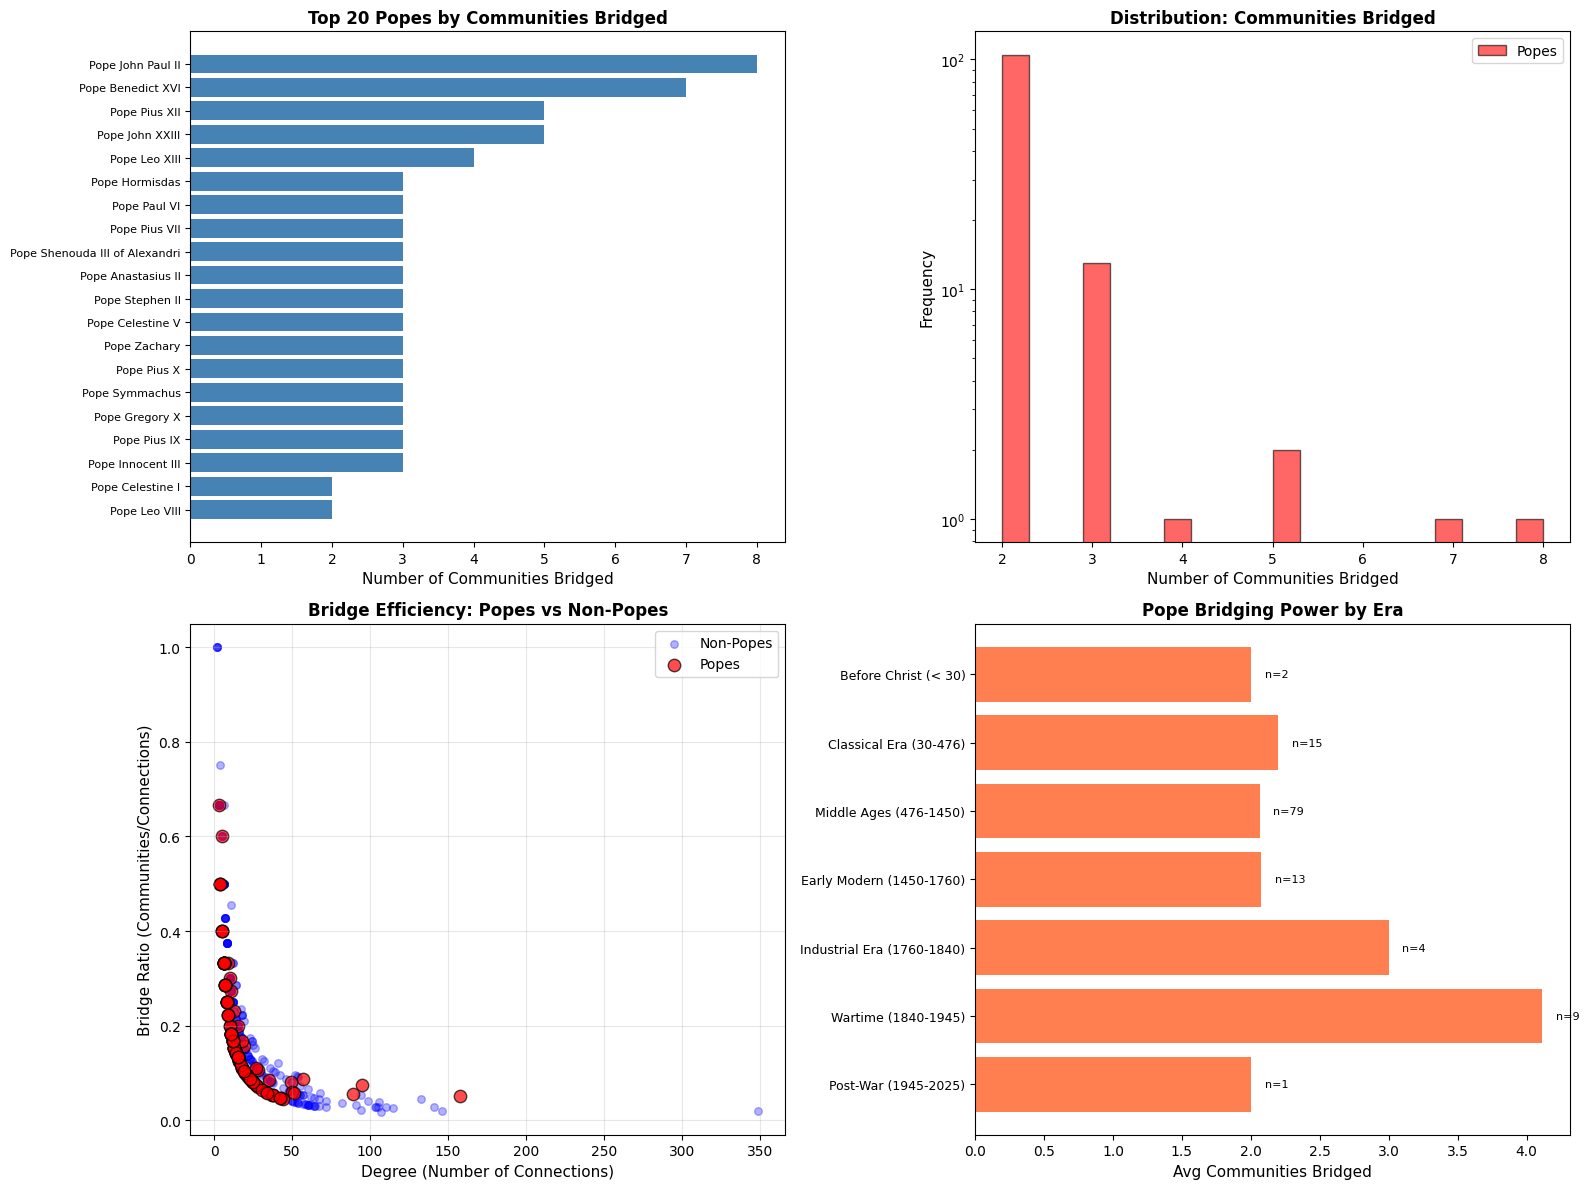


✓ Analysis complete!


In [14]:
# Step 1: Detect communities in the full network (excluding Popes first)
print("="*100)
print("ANALYZING: Do Popes Act as Bridges Between Historical Communities?")
print("="*100)

# Find all Pope nodes
pope_nodes = set()
for node in network.nodes():
    name = network.nodes[node].get('NameURL', '')
    if 'Pope' in name:
        pope_nodes.add(node)

print(f"\nFound {len(pope_nodes)} Pope nodes")

# Step 2: Create UNDIRECTED network WITHOUT Popes
non_pope_network = network.to_undirected()
non_pope_network.remove_nodes_from(pope_nodes)

print(f"\nNetwork without Popes:")
print(f"  Nodes: {non_pope_network.number_of_nodes()}")
print(f"  Edges: {non_pope_network.number_of_edges()}")

# Check connectivity
num_components_without_popes = nx.number_connected_components(non_pope_network)
print(f"  Connected components: {num_components_without_popes}")

# Step 3: Detect communities in non-Pope network
from collections import Counter
from networkx.algorithms import community

communities_without_popes = list(community.greedy_modularity_communities(non_pope_network))
print(f"\nCommunities detected (without Popes): {len(communities_without_popes)}")

# Analyze top communities
print("\nTop 5 Communities (without Popes):")
for i, comm in enumerate(sorted(communities_without_popes, key=len, reverse=True)[:5], 1):
    print(f"\n  Community {i}: {len(comm)} members")
    
    # Dominant eras
    eras = [get_era(network.nodes[node].get('birthyear')) for node in comm]
    era_counts = Counter(eras)
    print(f"    Top eras: {era_counts.most_common(3)}")
    
    # Dominant occupations
    occupations = [network.nodes[node].get('occupation', 'Unknown') for node in comm]
    occ_counts = Counter(occupations)
    print(f"    Top occupations: {occ_counts.most_common(3)}")
    
    # Dominant cities
    cities = [network.nodes[node].get('birthcity', 'Unknown') for node in comm]
    city_counts = Counter(cities)
    print(f"    Top cities: {city_counts.most_common(3)}")

# Step 4: Now analyze WITH Popes - do they connect these communities?
print("\n" + "="*100)
print("MEASURING POPE BRIDGING EFFECT")
print("="*100)

# Convert full network to undirected for neighbor analysis
network_undirected = network.to_undirected()

# For each Pope, count how many different communities they connect
pope_bridge_scores = []

for pope in pope_nodes:
    # Get neighbors of this Pope from undirected network
    neighbors = set(network_undirected.neighbors(pope))
    
    # Find which communities these neighbors belong to
    connected_communities = set()
    for neighbor in neighbors:
        for i, comm in enumerate(communities_without_popes):
            if neighbor in comm:
                connected_communities.add(i)
                break
    
    pope_name = network.nodes[pope].get('Name', pope)
    pope_era = get_era(network.nodes[pope].get('birthyear'))
    num_connections = len(neighbors)
    num_communities_bridged = len(connected_communities)
    
    if num_communities_bridged > 1:  # Only count if bridging at least 2 communities
        pope_bridge_scores.append({
            'name': pope_name,
            'era': pope_era,
            'degree': num_connections,
            'communities_bridged': num_communities_bridged,
            'bridge_ratio': num_communities_bridged / num_connections if num_connections > 0 else 0
        })

# Sort by communities bridged
pope_bridge_scores.sort(key=lambda x: x['communities_bridged'], reverse=True)

print(f"\nTop 20 Popes by Number of Communities Bridged:")
print("-"*100)
print(f"{'Rank':<6} {'Name':<45} {'Era':<25} {'Degree':<10} {'Communities':<12}")
print("-"*100)

for rank, pope in enumerate(pope_bridge_scores[:20], 1):
    print(f"{rank:<6} {pope['name']:<45} {pope['era']:<25} {pope['degree']:<10} {pope['communities_bridged']:<12}")

# Step 5: Statistical analysis - Are Popes better bridges than non-Popes?
print("\n" + "="*100)
print("STATISTICAL COMPARISON: Popes vs Non-Popes as Bridges")
print("="*100)

# Calculate bridging scores for non-Popes too
non_pope_bridge_scores = []

for node in network_undirected.nodes():
    if node not in pope_nodes:
        neighbors = set(network_undirected.neighbors(node))
        
        connected_communities = set()
        for neighbor in neighbors:
            for i, comm in enumerate(communities_without_popes):
                if neighbor in comm:
                    connected_communities.add(i)
                    break
        
        num_connections = len(neighbors)
        num_communities_bridged = len(connected_communities)
        
        if num_connections > 0 and num_communities_bridged > 1:
            non_pope_bridge_scores.append({
                'degree': num_connections,
                'communities_bridged': num_communities_bridged,
                'bridge_ratio': num_communities_bridged / num_connections
            })

# Compare statistics
pope_avg_communities = np.mean([p['communities_bridged'] for p in pope_bridge_scores])
pope_avg_ratio = np.mean([p['bridge_ratio'] for p in pope_bridge_scores])

non_pope_avg_communities = np.mean([p['communities_bridged'] for p in non_pope_bridge_scores])
non_pope_avg_ratio = np.mean([p['bridge_ratio'] for p in non_pope_bridge_scores])

print(f"\nPopes:")
print(f"  Average communities bridged: {pope_avg_communities:.2f}")
print(f"  Average bridge ratio: {pope_avg_ratio:.4f}")
print(f"  Sample size: {len(pope_bridge_scores)}")

print(f"\nNon-Popes:")
print(f"  Average communities bridged: {non_pope_avg_communities:.2f}")
print(f"  Average bridge ratio: {non_pope_avg_ratio:.4f}")
print(f"  Sample size: {len(non_pope_bridge_scores)}")

print(f"\nDifference:")
print(f"  Popes bridge {(pope_avg_communities/non_pope_avg_communities - 1)*100:.1f}% more communities on average")

# Step 6: Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Communities bridged by top Popes
ax1 = axes[0, 0]
top_20_popes = pope_bridge_scores[:20]
y_pos = range(len(top_20_popes))
ax1.barh(y_pos, [p['communities_bridged'] for p in top_20_popes], color='steelblue')
ax1.set_yticks(y_pos)
ax1.set_yticklabels([p['name'][:30] for p in top_20_popes], fontsize=8)
ax1.set_xlabel('Number of Communities Bridged', fontsize=11)
ax1.set_title('Top 20 Popes by Communities Bridged', fontsize=12, fontweight='bold')
ax1.invert_yaxis()

# Plot 2: Distribution comparison
ax2 = axes[0, 1]
pope_communities_list = [p['communities_bridged'] for p in pope_bridge_scores]
non_pope_communities_list = [p['communities_bridged'] for p in non_pope_bridge_scores]

ax2.hist(pope_communities_list, bins=20, alpha=0.6, label='Popes', color='red', edgecolor='black')
ax2.set_xlabel('Number of Communities Bridged', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Distribution: Communities Bridged', fontsize=12, fontweight='bold')
ax2.legend()
ax2.set_yscale('log')

# Plot 3: Bridge ratio by degree (scatter)
ax3 = axes[1, 0]
ax3.scatter([p['degree'] for p in non_pope_bridge_scores[:500]], 
           [p['bridge_ratio'] for p in non_pope_bridge_scores[:500]], 
           alpha=0.3, s=30, label='Non-Popes', color='blue')
ax3.scatter([p['degree'] for p in pope_bridge_scores], 
           [p['bridge_ratio'] for p in pope_bridge_scores], 
           alpha=0.7, s=80, label='Popes', color='red', edgecolors='black')
ax3.set_xlabel('Degree (Number of Connections)', fontsize=11)
ax3.set_ylabel('Bridge Ratio (Communities/Connections)', fontsize=11)
ax3.set_title('Bridge Efficiency: Popes vs Non-Popes', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Popes bridging over time (by era)
ax4 = axes[1, 1]
era_bridge_data = defaultdict(list)
for pope in pope_bridge_scores:
    era_bridge_data[pope['era']].append(pope['communities_bridged'])

era_avgs = []
for era in era_order_display:
    if era in era_bridge_data:
        era_avgs.append({
            'era': era,
            'avg_bridged': np.mean(era_bridge_data[era]),
            'count': len(era_bridge_data[era])
        })

if era_avgs:
    y_pos = range(len(era_avgs))
    ax4.barh(y_pos, [e['avg_bridged'] for e in era_avgs], color='coral')
    ax4.set_yticks(y_pos)
    ax4.set_yticklabels([e['era'] for e in era_avgs], fontsize=9)
    ax4.set_xlabel('Avg Communities Bridged', fontsize=11)
    ax4.set_title('Pope Bridging Power by Era', fontsize=12, fontweight='bold')
    ax4.invert_yaxis()
    
    # Add count labels
    for i, e in enumerate(era_avgs):
        ax4.text(e['avg_bridged'] + 0.1, i, f"n={e['count']}", va='center', fontsize=8)

plt.tight_layout()
plt.show()

print("\n✓ Analysis complete!")

In [15]:
# Statistical significance test
from scipy import stats

pope_communities = [p['communities_bridged'] for p in pope_bridge_scores]
non_pope_communities = [p['communities_bridged'] for p in non_pope_bridge_scores]

# Mann-Whitney U test (non-parametric)
statistic, p_value = stats.mannwhitneyu(pope_communities, non_pope_communities, alternative='greater')

print(f"\nStatistical Test (Mann-Whitney U):")
print(f"  p-value: {p_value:.4f}")
if p_value < 0.05:
    print(f"  Result: Popes bridge significantly more communities (p < 0.05) ✓")
else:
    print(f"  Result: No significant difference (p ≥ 0.05)")


Statistical Test (Mann-Whitney U):
  p-value: 0.9991
  Result: No significant difference (p ≥ 0.05)


WHICH OCCUPATIONS ARE THE BEST BRIDGES?

Top 20 Occupations by Average Communities Bridged:
------------------------------------------------------------------------------------------------------------------------
Rank   Occupation                          Count    Avg Comm     Max Comm     Avg Ratio   
------------------------------------------------------------------------------------------------------------------------
1      DIPLOMAT                            23       2.83         7            0.2366      
2      BASEBALL PLAYER                     5        2.80         3            0.2635      
3      PRODUCER                            8        2.75         5            0.1607      
4      PRESENTER                           15       2.73         4            0.1169      
5      ECONOMIST                           67       2.70         7            0.3267      
6      BOXER                               10       2.70         5            0.1632      
7      COMIC ARTIST          

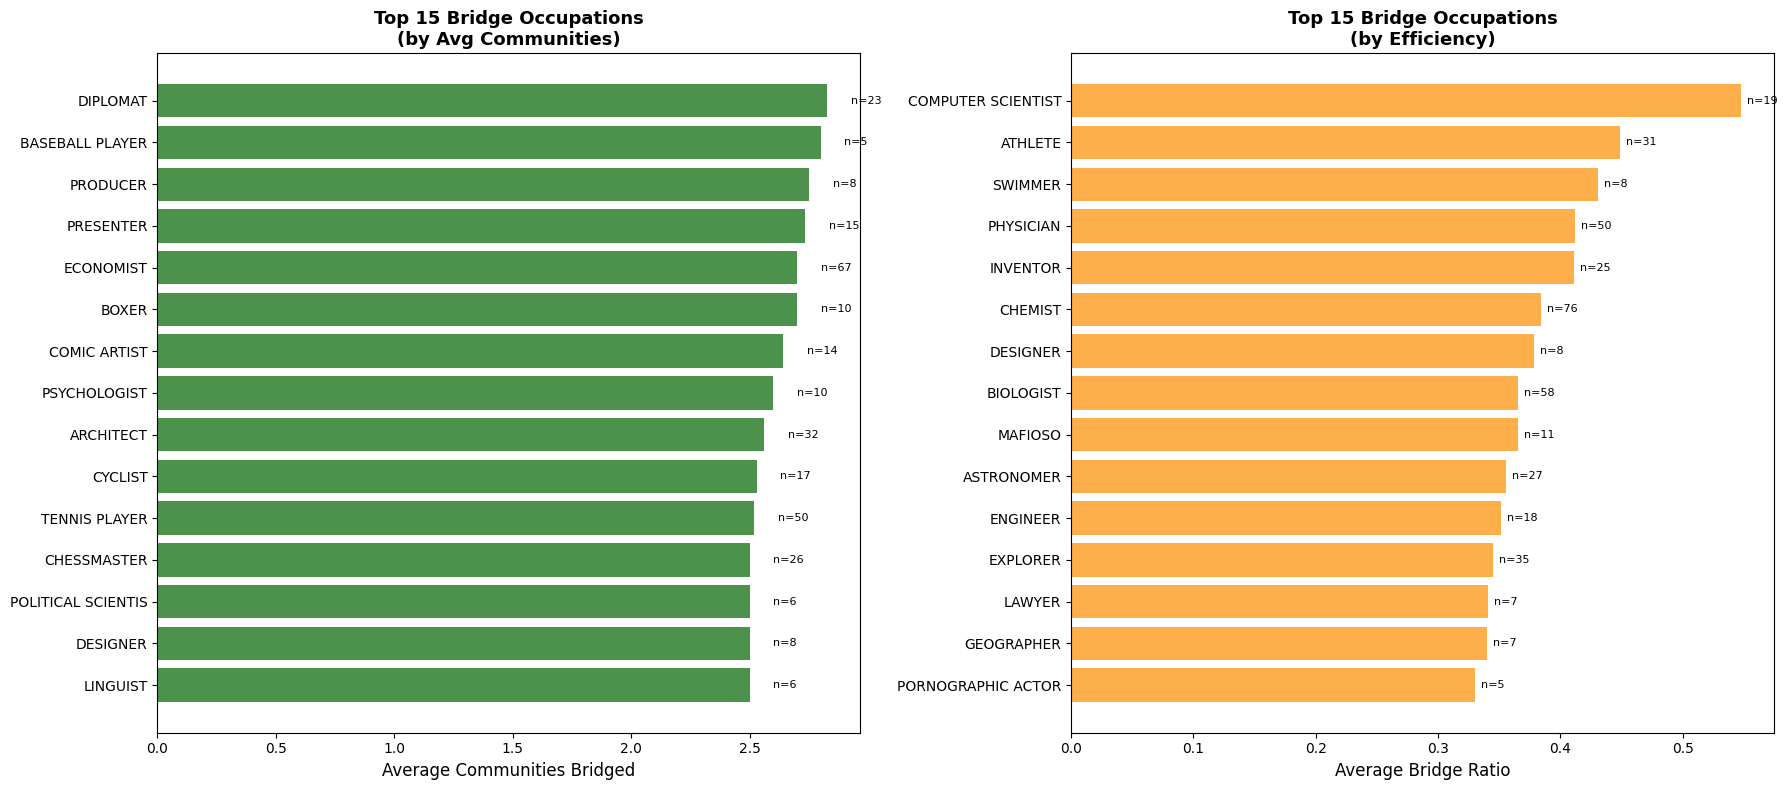


COMPARISON: Top Occupation vs Popes

Top Bridging Occupation: DIPLOMAT
  Average communities bridged: 2.83
  Average bridge ratio: 0.2366
  Sample size: 23

Popes:
  Average communities bridged: 2.26
  Average bridge ratio: 0.1823
  Sample size: 123

DIPLOMATs bridge +25.0% communities compared to Popes

✓ Occupation analysis complete!


In [16]:
# Find top bridging occupations
print("="*100)
print("WHICH OCCUPATIONS ARE THE BEST BRIDGES?")
print("="*100)

# Collect bridging data by occupation
occupation_bridge_data = defaultdict(list)

for node in network_undirected.nodes():
    neighbors = set(network_undirected.neighbors(node))
    
    connected_communities = set()
    for neighbor in neighbors:
        for i, comm in enumerate(communities_without_popes):
            if neighbor in comm:
                connected_communities.add(i)
                break
    
    num_connections = len(neighbors)
    num_communities_bridged = len(connected_communities)
    
    if num_connections > 0 and num_communities_bridged > 1:
        occupation = network.nodes[node].get('occupation', 'Unknown')
        occupation_bridge_data[occupation].append({
            'degree': num_connections,
            'communities_bridged': num_communities_bridged,
            'bridge_ratio': num_communities_bridged / num_connections
        })

# Calculate statistics per occupation
occupation_stats = []

for occupation, bridges in occupation_bridge_data.items():
    if len(bridges) >= 5:  # Only occupations with at least 5 bridging members
        occupation_stats.append({
            'occupation': occupation,
            'count': len(bridges),
            'avg_communities': np.mean([b['communities_bridged'] for b in bridges]),
            'avg_ratio': np.mean([b['bridge_ratio'] for b in bridges]),
            'max_communities': max([b['communities_bridged'] for b in bridges]),
            'median_communities': np.median([b['communities_bridged'] for b in bridges])
        })

# Sort by average communities bridged
occupation_stats.sort(key=lambda x: x['avg_communities'], reverse=True)

print(f"\nTop 20 Occupations by Average Communities Bridged:")
print("-"*120)
print(f"{'Rank':<6} {'Occupation':<35} {'Count':<8} {'Avg Comm':<12} {'Max Comm':<12} {'Avg Ratio':<12}")
print("-"*120)

for rank, occ in enumerate(occupation_stats[:20], 1):
    print(f"{rank:<6} {occ['occupation']:<35} {occ['count']:<8} {occ['avg_communities']:<12.2f} {occ['max_communities']:<12} {occ['avg_ratio']:<12.4f}")

# Visualization: Top 15 occupations
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot 1: Average communities bridged
ax1 = axes[0]
top_15_occs = occupation_stats[:15]
y_pos = range(len(top_15_occs))
ax1.barh(y_pos, [o['avg_communities'] for o in top_15_occs], color='darkgreen', alpha=0.7)
ax1.set_yticks(y_pos)
ax1.set_yticklabels([o['occupation'][:30] for o in top_15_occs], fontsize=10)
ax1.set_xlabel('Average Communities Bridged', fontsize=12)
ax1.set_title('Top 15 Bridge Occupations\n(by Avg Communities)', fontsize=13, fontweight='bold')
ax1.invert_yaxis()

# Add count labels
for i, occ in enumerate(top_15_occs):
    ax1.text(occ['avg_communities'] + 0.1, i, f"n={occ['count']}", va='center', fontsize=8)

# Plot 2: Bridge ratio comparison
ax2 = axes[1]
occupation_stats_by_ratio = sorted(occupation_stats, key=lambda x: x['avg_ratio'], reverse=True)[:15]
y_pos = range(len(occupation_stats_by_ratio))
ax2.barh(y_pos, [o['avg_ratio'] for o in occupation_stats_by_ratio], color='darkorange', alpha=0.7)
ax2.set_yticks(y_pos)
ax2.set_yticklabels([o['occupation'][:30] for o in occupation_stats_by_ratio], fontsize=10)
ax2.set_xlabel('Average Bridge Ratio', fontsize=12)
ax2.set_title('Top 15 Bridge Occupations\n(by Efficiency)', fontsize=13, fontweight='bold')
ax2.invert_yaxis()

# Add count labels
for i, occ in enumerate(occupation_stats_by_ratio):
    ax2.text(occ['avg_ratio'] + 0.005, i, f"n={occ['count']}", va='center', fontsize=8)

plt.tight_layout()
plt.show()

# Compare top occupation to Popes
if pope_bridge_scores:
    top_occupation = occupation_stats[0]
    print(f"\n" + "="*100)
    print(f"COMPARISON: Top Occupation vs Popes")
    print("="*100)
    print(f"\nTop Bridging Occupation: {top_occupation['occupation']}")
    print(f"  Average communities bridged: {top_occupation['avg_communities']:.2f}")
    print(f"  Average bridge ratio: {top_occupation['avg_ratio']:.4f}")
    print(f"  Sample size: {top_occupation['count']}")
    
    print(f"\nPopes:")
    print(f"  Average communities bridged: {pope_avg_communities:.2f}")
    print(f"  Average bridge ratio: {pope_avg_ratio:.4f}")
    print(f"  Sample size: {len(pope_bridge_scores)}")
    
    diff = ((top_occupation['avg_communities'] / pope_avg_communities) - 1) * 100
    print(f"\n{top_occupation['occupation']}s bridge {diff:+.1f}% communities compared to Popes")

print("\n✓ Occupation analysis complete!")

In [17]:
# Find communities that are bridged primarily by Popes
print("="*100)
print("WHICH COMMUNITIES DO POPES PRIMARILY BRIDGE?")
print("="*100)

# For each pair of communities, count how many Popes vs non-Popes bridge them
from itertools import combinations

community_pair_bridges = defaultdict(lambda: {'pope_bridges': 0, 'non_pope_bridges': 0, 'total_bridges': 0})

# Check all nodes
for node in network_undirected.nodes():
    neighbors = set(network_undirected.neighbors(node))
    
    # Find which communities the neighbors belong to
    neighbor_communities = set()
    for neighbor in neighbors:
        for i, comm in enumerate(communities_without_popes):
            if neighbor in comm:
                neighbor_communities.add(i)
                break
    
    # If this node bridges at least 2 communities
    if len(neighbor_communities) >= 2:
        is_pope = node in pope_nodes
        
        # Count bridges between each pair of communities
        for comm1, comm2 in combinations(sorted(neighbor_communities), 2):
            pair_key = (comm1, comm2)
            community_pair_bridges[pair_key]['total_bridges'] += 1
            if is_pope:
                community_pair_bridges[pair_key]['pope_bridges'] += 1
            else:
                community_pair_bridges[pair_key]['non_pope_bridges'] += 1

# Find community pairs where Popes are dominant bridges
pope_dominated_pairs = []

for (comm1, comm2), counts in community_pair_bridges.items():
    if counts['total_bridges'] >= 5:  # At least 5 total bridges
        pope_ratio = counts['pope_bridges'] / counts['total_bridges']
        if pope_ratio >= 0.3:  # Popes account for 30%+ of bridges
            pope_dominated_pairs.append({
                'comm1': comm1,
                'comm2': comm2,
                'pope_bridges': counts['pope_bridges'],
                'non_pope_bridges': counts['non_pope_bridges'],
                'total_bridges': counts['total_bridges'],
                'pope_ratio': pope_ratio
            })

# Sort by Pope ratio
pope_dominated_pairs.sort(key=lambda x: x['pope_ratio'], reverse=True)

print(f"\nCommunity Pairs Where Popes Are Primary Bridges (≥30% Pope bridges):")
print("-"*120)
print(f"{'Rank':<6} {'Comm 1':<10} {'Comm 2':<10} {'Pope Bridges':<15} {'Non-Pope':<15} {'Total':<10} {'Pope %':<10}")
print("-"*120)

for rank, pair in enumerate(pope_dominated_pairs[:20], 1):
    print(f"{rank:<6} {pair['comm1']:<10} {pair['comm2']:<10} {pair['pope_bridges']:<15} "
          f"{pair['non_pope_bridges']:<15} {pair['total_bridges']:<10} {pair['pope_ratio']*100:<10.1f}")

# Analyze the top Pope-dominated community pair
if pope_dominated_pairs:
    print(f"\n" + "="*100)
    print("ANALYZING TOP POPE-BRIDGED COMMUNITY PAIR")
    print("="*100)
    
    top_pair = pope_dominated_pairs[0]
    comm1_idx = top_pair['comm1']
    comm2_idx = top_pair['comm2']
    
    # Get the actual communities
    all_communities_sorted = sorted(communities_without_popes, key=len, reverse=True)
    comm1 = all_communities_sorted[comm1_idx]
    comm2 = all_communities_sorted[comm2_idx]
    
    print(f"\nCommunity {comm1_idx} ({len(comm1)} members):")
    # Analyze community 1
    eras1 = [get_era(network.nodes[node].get('birthyear')) for node in comm1]
    era_counts1 = Counter(eras1)
    print(f"  Top eras: {era_counts1.most_common(3)}")
    
    occupations1 = [network.nodes[node].get('occupation', 'Unknown') for node in comm1]
    occ_counts1 = Counter(occupations1)
    print(f"  Top occupations: {occ_counts1.most_common(3)}")
    
    cities1 = [network.nodes[node].get('birthcity', 'Unknown') for node in comm1]
    city_counts1 = Counter(cities1)
    print(f"  Top cities: {city_counts1.most_common(3)}")
    
    print(f"\nCommunity {comm2_idx} ({len(comm2)} members):")
    # Analyze community 2
    eras2 = [get_era(network.nodes[node].get('birthyear')) for node in comm2]
    era_counts2 = Counter(eras2)
    print(f"  Top eras: {era_counts2.most_common(3)}")
    
    occupations2 = [network.nodes[node].get('occupation', 'Unknown') for node in comm2]
    occ_counts2 = Counter(occupations2)
    print(f"  Top occupations: {occ_counts2.most_common(3)}")
    
    cities2 = [network.nodes[node].get('birthcity', 'Unknown') for node in comm2]
    city_counts2 = Counter(cities2)
    print(f"  Top cities: {city_counts2.most_common(3)}")
    
    # Find which Popes bridge these two communities
    bridging_popes = []
    for pope in pope_nodes:
        neighbors = set(network_undirected.neighbors(pope))
        
        has_comm1_neighbor = any(n in comm1 for n in neighbors)
        has_comm2_neighbor = any(n in comm2 for n in neighbors)
        
        if has_comm1_neighbor and has_comm2_neighbor:
            pope_name = network.nodes[pope].get('Name', pope)
            pope_era = get_era(network.nodes[pope].get('birthyear'))
            bridging_popes.append({'name': pope_name, 'era': pope_era})
    
    print(f"\nPopes bridging these communities ({len(bridging_popes)}):")
    for pope in bridging_popes[:10]:
        print(f"  - {pope['name']} ({pope['era']})")

print("\n✓ Community pair analysis complete!")

WHICH COMMUNITIES DO POPES PRIMARILY BRIDGE?

Community Pairs Where Popes Are Primary Bridges (≥30% Pope bridges):
------------------------------------------------------------------------------------------------------------------------
Rank   Comm 1     Comm 2     Pope Bridges    Non-Pope        Total      Pope %    
------------------------------------------------------------------------------------------------------------------------
1      0          132        5               0               5          100.0     

ANALYZING TOP POPE-BRIDGED COMMUNITY PAIR

Community 0 (4131 members):
  Top eras: [('Wartime (1840-1945)', 1702), ('Early Modern (1450-1760)', 778), ('Industrial Era (1760-1840)', 669)]
  Top occupations: [('POLITICIAN', 1037), ('WRITER', 768), ('PHILOSOPHER', 266)]
  Top cities: [('OTHER', 233), ('PARIS', 166), ('LONDON', 89)]

Community 132 (1 members):
  Top eras: [('Industrial Era (1760-1840)', 1)]
  Top occupations: [('RELIGIOUS FIGURE', 1)]
  Top cities: [('DARDILL

In [18]:
# After the table, add:
exclusive_pope_pairs = [p for p in pope_dominated_pairs if p['pope_ratio'] == 1.0]
print(f"\n✓ Found {len(exclusive_pope_pairs)} community pairs EXCLUSIVELY bridged by Popes (100%)")


✓ Found 1 community pairs EXCLUSIVELY bridged by Popes (100%)


In [19]:
# Check if removing Popes creates isolated communities
print("="*100)
print("CHECKING IF POPES CREATE ISOLATION WHEN REMOVED")
print("="*100)

# 1. Start with the full undirected network
full_network = network.to_undirected()

# 2. Find connected components WITH Popes
components_with_popes = list(nx.connected_components(full_network))
num_components_with = len(components_with_popes)

print(f"\nWith Popes:")
print(f"  Connected components: {num_components_with}")
print(f"  Largest component size: {len(max(components_with_popes, key=len))}")

# 3. Remove Popes and check again
network_without_popes = full_network.copy()
network_without_popes.remove_nodes_from(pope_nodes)

components_without_popes = list(nx.connected_components(network_without_popes))
num_components_without = len(components_without_popes)

print(f"\nWithout Popes:")
print(f"  Connected components: {num_components_without}")
print(f"  Largest component size: {len(max(components_without_popes, key=len))}")

# 4. Calculate the increase in isolation
new_components = num_components_without - num_components_with
print(f"\n✓ Removing Popes creates {new_components} additional isolated components")

if new_components > 0:
    print(f"  → This means Popes were connecting {new_components} previously connected parts!")
else:
    print(f"  → Popes don't create new isolated components")

# 5. Find which nodes become isolated (if any)
# Nodes that lose connectivity when Popes are removed
newly_isolated_nodes = set()
for component in components_without_popes:
    if len(component) == 1:
        newly_isolated_nodes.update(component)

print(f"\nNodes that become isolated: {len(newly_isolated_nodes)}")

# 6. Check if any of the exclusive Pope-bridged community pairs become disconnected
if exclusive_pope_pairs:
    print(f"\nChecking {len(exclusive_pope_pairs)} exclusively Pope-bridged community pairs:")
    
    disconnected_pairs = 0
    for pair in exclusive_pope_pairs:
        comm1_idx = pair['comm1']
        comm2_idx = pair['comm2']
        
        all_communities_sorted = sorted(communities_without_popes, key=len, reverse=True)
        comm1_nodes = all_communities_sorted[comm1_idx]
        comm2_nodes = all_communities_sorted[comm2_idx]
        
        # Pick sample nodes from each community
        sample1 = list(comm1_nodes)[0]
        sample2 = list(comm2_nodes)[0]
        
        # Check if there's a path WITHOUT Popes
        try:
            path = nx.shortest_path(network_without_popes, sample1, sample2)
            # Path exists without Popes
        except nx.NetworkXNoPath:
            disconnected_pairs += 1
    
    print(f"  → {disconnected_pairs}/{len(exclusive_pope_pairs)} pairs become completely disconnected")

CHECKING IF POPES CREATE ISOLATION WHEN REMOVED

With Popes:
  Connected components: 233
  Largest component size: 11023

Without Popes:
  Connected components: 236
  Largest component size: 10754

✓ Removing Popes creates 3 additional isolated components
  → This means Popes were connecting 3 previously connected parts!

Nodes that become isolated: 209

Checking 1 exclusively Pope-bridged community pairs:
  → 1/1 pairs become completely disconnected


In [20]:
# Detailed analysis of disconnected community pairs
if exclusive_pope_pairs and disconnected_pairs > 0:
    print(f"\n" + "="*100)
    print("DETAILED ANALYSIS: Which Communities Become Disconnected?")
    print("="*100)
    
    all_communities_sorted = sorted(communities_without_popes, key=len, reverse=True)
    
    disconnected_details = []
    
    for pair in exclusive_pope_pairs:
        comm1_idx = pair['comm1']
        comm2_idx = pair['comm2']
        
        comm1_nodes = all_communities_sorted[comm1_idx]
        comm2_nodes = all_communities_sorted[comm2_idx]
        
        # Pick sample nodes from each community
        sample1 = list(comm1_nodes)[0]
        sample2 = list(comm2_nodes)[0]
        
        # Check if there's a path WITHOUT Popes
        try:
            path = nx.shortest_path(network_without_popes, sample1, sample2)
            is_disconnected = False
        except nx.NetworkXNoPath:
            is_disconnected = True
        
        if is_disconnected:
            # Analyze both communities
            comm1 = comm1_nodes
            comm2 = comm2_nodes
            
            # Community 1 characteristics
            eras1 = [get_era(network.nodes[node].get('birthyear')) for node in comm1]
            era_counts1 = Counter(eras1)
            occupations1 = [network.nodes[node].get('occupation', 'Unknown') for node in comm1]
            occ_counts1 = Counter(occupations1)
            
            # Community 2 characteristics
            eras2 = [get_era(network.nodes[node].get('birthyear')) for node in comm2]
            era_counts2 = Counter(eras2)
            occupations2 = [network.nodes[node].get('occupation', 'Unknown') for node in comm2]
            occ_counts2 = Counter(occupations2)
            
            # Find which Popes bridge them
            bridging_popes_list = []
            for pope in pope_nodes:
                neighbors = set(network_undirected.neighbors(pope))
                has_comm1 = any(n in comm1 for n in neighbors)
                has_comm2 = any(n in comm2 for n in neighbors)
                if has_comm1 and has_comm2:
                    bridging_popes_list.append(network.nodes[pope].get('Name', pope))
            
            disconnected_details.append({
                'comm1_idx': comm1_idx,
                'comm2_idx': comm2_idx,
                'comm1_size': len(comm1),
                'comm2_size': len(comm2),
                'comm1_top_era': era_counts1.most_common(1)[0] if era_counts1 else ('Unknown', 0),
                'comm2_top_era': era_counts2.most_common(1)[0] if era_counts2 else ('Unknown', 0),
                'comm1_top_occ': occ_counts1.most_common(1)[0] if occ_counts1 else ('Unknown', 0),
                'comm2_top_occ': occ_counts2.most_common(1)[0] if occ_counts2 else ('Unknown', 0),
                'bridging_popes': bridging_popes_list,
                'num_pope_bridges': len(bridging_popes_list)
            })
    
    # Display disconnected pairs
    print(f"\nFound {len(disconnected_details)} community pairs that become COMPLETELY DISCONNECTED:")
    print("-"*120)
    
    for i, detail in enumerate(disconnected_details, 1):
        print(f"\nPair {i}: Communities {detail['comm1_idx']} ↔ {detail['comm2_idx']}")
        print(f"  Community {detail['comm1_idx']}: {detail['comm1_size']} members")
        print(f"    Dominant era: {detail['comm1_top_era'][0]} ({detail['comm1_top_era'][1]} members)")
        print(f"    Dominant occupation: {detail['comm1_top_occ'][0]} ({detail['comm1_top_occ'][1]} members)")
        
        print(f"  Community {detail['comm2_idx']}: {detail['comm2_size']} members")
        print(f"    Dominant era: {detail['comm2_top_era'][0]} ({detail['comm2_top_era'][1]} members)")
        print(f"    Dominant occupation: {detail['comm2_top_occ'][0]} ({detail['comm2_top_occ'][1]} members)")
        
        print(f"  Pope bridges ({detail['num_pope_bridges']}): {', '.join(detail['bridging_popes'][:5])}")
        if len(detail['bridging_popes']) > 5:
            print(f"    ... and {len(detail['bridging_popes']) - 5} more")
    
    print("\n" + "="*100)
    print("KEY FINDING:")
    print(f"Without these {sum([d['num_pope_bridges'] for d in disconnected_details])} Pope connections,")
    print(f"{len(disconnected_details)} community pairs would have NO path between them.")
    print("="*100)

print("\n✓ Disconnection analysis complete!")


DETAILED ANALYSIS: Which Communities Become Disconnected?

Found 1 community pairs that become COMPLETELY DISCONNECTED:
------------------------------------------------------------------------------------------------------------------------

Pair 1: Communities 0 ↔ 132
  Community 0: 4131 members
    Dominant era: Wartime (1840-1945) (1702 members)
    Dominant occupation: POLITICIAN (1037 members)
  Community 132: 1 members
    Dominant era: Industrial Era (1760-1840) (1 members)
    Dominant occupation: RELIGIOUS FIGURE (1 members)
  Pope bridges (5): Pope Pius XI, Pope Pius X, Pope John XXIII, Pope Pius IX, Pope Benedict XVI

KEY FINDING:
Without these 5 Pope connections,
1 community pairs would have NO path between them.

✓ Disconnection analysis complete!


In [21]:
# 5. Find which nodes become isolated (if any)
# Nodes that lose connectivity when Popes are removed
newly_isolated_nodes = set()
for component in components_without_popes:
    if len(component) == 1:
        newly_isolated_nodes.update(component)

print(f"\nNodes that become isolated: {len(newly_isolated_nodes)}")


Nodes that become isolated: 209


In [22]:
# 5. Find which nodes become isolated (if any)
# Nodes that lose connectivity when Popes are removed
newly_isolated_nodes = set()
for component in components_without_popes:
    if len(component) == 1:
        newly_isolated_nodes.update(component)

print(f"\nNodes that become isolated: {len(newly_isolated_nodes)}")

# Show details of isolated nodes
if newly_isolated_nodes:
    print(f"\nDetailed list of isolated nodes:")
    print("-"*120)
    print(f"{'Name':<50} {'Occupation':<30} {'Era':<30}")
    print("-"*120)
    
    for node in list(newly_isolated_nodes)[:50]:  # Show first 50
        node_name = network.nodes[node].get('Name', 'Unknown')
        occupation = network.nodes[node].get('occupation', 'Unknown')
        era = get_era(network.nodes[node].get('birthyear'))
        print(f"{node_name:<50} {occupation:<30} {era:<30}")
    
    if len(newly_isolated_nodes) > 50:
        print(f"\n... and {len(newly_isolated_nodes) - 50} more isolated nodes")


Nodes that become isolated: 209

Detailed list of isolated nodes:
------------------------------------------------------------------------------------------------------------------------
Name                                               Occupation                     Era                           
------------------------------------------------------------------------------------------------------------------------
Ji Yun-Nam                                         SOCCER PLAYER                  Post-War (1945-2025)          
Jorge Garcia                                       ACTOR                          Post-War (1945-2025)          
Robert Bruce Merrifield                            CHEMIST                        Wartime (1840-1945)           
Uche Kalu                                          SOCCER PLAYER                  Post-War (1945-2025)          
Nikolai Ostrovsky                                  WRITER                         Wartime (1840-1945)           
Yakub Kolas  

In [23]:
# Load the network
url = "https://raw.githubusercontent.com/denisababeii/socialgraphs_project/refs/heads/main/celebrities_clean_without_content.graphml"
    
try:
    with urllib.request.urlopen(url) as response:
        data = response.read()
        
    network = nx.read_graphml(io.BytesIO(data))
    print(f"✓ Network loaded successfully!")
    print(f"  Nodes: {network.number_of_nodes()}")
    print(f"  Edges: {network.number_of_edges()}")
        
except Exception as e:
    print(f"✗ Error loading network: {str(e)}")
    network = None

✓ Network loaded successfully!
  Nodes: 11286
  Edges: 125705


In [24]:
# Find critical bridge nodes that disconnect large communities
print("="*100)
print("CRITICAL BRIDGE NODES: Single Points of Failure")
print("="*100)

# Get the largest connected component
full_network = network.to_undirected()
largest_component = max(nx.connected_components(full_network), key=len)
largest_subgraph = full_network.subgraph(largest_component).copy()

print(f"\nLargest connected component: {len(largest_component)} nodes")

# Find articulation points (cut vertices)
articulation_points = list(nx.articulation_points(largest_subgraph))
print(f"Found {len(articulation_points)} articulation points (critical bridge nodes)")

# For each articulation point, measure impact of removal
critical_bridges = []

for node in articulation_points:
    # Create network without this node
    temp_network = largest_subgraph.copy()
    temp_network.remove_node(node)
    
    # Find resulting components
    components = list(nx.connected_components(temp_network))
    
    # Get sizes of top 2 components created
    component_sizes = sorted([len(c) for c in components], reverse=True)
    
    if len(component_sizes) >= 2:
        node_name = network.nodes[node].get('Name', 'Unknown')
        occupation = network.nodes[node].get('occupation', 'Unknown')
        era = get_era(network.nodes[node].get('birthyear'))
        is_pope = 'Pope' in network.nodes[node].get('NameURL', '')
        
        critical_bridges.append({
            'node': node,
            'name': node_name,
            'occupation': occupation,
            'era': era,
            'is_pope': is_pope,
            'num_components': len(components),
            'largest_component': component_sizes[0],
            'second_largest': component_sizes[1],
            'total_disconnected': component_sizes[0] + component_sizes[1],
            'impact_score': component_sizes[0] * component_sizes[1]  # Product = measure of "balanced split"
        })

# Sort by impact score (larger = more balanced/severe split)
critical_bridges.sort(key=lambda x: x['impact_score'], reverse=True)

print(f"\nTop 20 Most Critical Bridge Nodes:")
print("-"*130)
print(f"{'Rank':<6} {'Name':<40} {'Occupation':<25} {'Era':<20} {'Pope':<7} {'Split (A/B)':<20}")
print("-"*130)

for rank, bridge in enumerate(critical_bridges[:20], 1):
    pope_mark = "✓" if bridge['is_pope'] else ""
    split_info = f"{bridge['largest_component']}/{bridge['second_largest']}"
    print(f"{rank:<6} {bridge['name'][:38]:<40} {bridge['occupation'][:23]:<25} "
          f"{bridge['era'][:18]:<20} {pope_mark:<7} {split_info:<20}")

# Count how many are Popes
pope_critical = sum(1 for b in critical_bridges if b['is_pope'])
print(f"\n✓ {pope_critical}/{len(critical_bridges)} critical bridges are Popes ({pope_critical/len(critical_bridges)*100:.1f}%)")

# Find the most severe disconnection
if critical_bridges:
    top_bridge = critical_bridges[0]
    print(f"\n" + "="*100)
    print("MOST CRITICAL BRIDGE NODE:")
    print("="*100)
    print(f"Name: {top_bridge['name']}")
    print(f"Occupation: {top_bridge['occupation']}")
    print(f"Era: {top_bridge['era']}")
    print(f"Is Pope: {'Yes' if top_bridge['is_pope'] else 'No'}")
    print(f"\nImpact of removal:")
    print(f"  Creates {top_bridge['num_components']} separate components")
    print(f"  Largest component: {top_bridge['largest_component']} nodes")
    print(f"  Second largest: {top_bridge['second_largest']} nodes")
    print(f"  Total disconnected: {top_bridge['total_disconnected']} nodes")
    print(f"  Impact score: {top_bridge['impact_score']:,}")

CRITICAL BRIDGE NODES: Single Points of Failure

Largest connected component: 11023 nodes
Found 400 articulation points (critical bridge nodes)

Top 20 Most Critical Bridge Nodes:
----------------------------------------------------------------------------------------------------------------------------------
Rank   Name                                     Occupation                Era                  Pope    Split (A/B)         
----------------------------------------------------------------------------------------------------------------------------------
1      Queen Sonja of Norway                    COMPANION                 Wartime (1840-1945           11016/6             
2      Simon Ammann                             SKIER                     Post-War (1945-202           11017/5             
3      Lance Armstrong                          CYCLIST                   Post-War (1945-202           11017/5             
4      Georg Wittig                             CHEMIST       

In [25]:
# Analyze Queen Sonja's critical bridge role
print("="*100)
print("ANALYZING QUEEN SONJA OF NORWAY'S BRIDGE ROLE")
print("="*100)

# Find Queen Sonja's node
queen_sonja_node = None
for node in network.nodes():
    if 'Queen Sonja of Norway' in network.nodes[node].get('Name', ''):
        queen_sonja_node = node
        break

if queen_sonja_node:
    print(f"\nFound Queen Sonja: {network.nodes[queen_sonja_node].get('Name')}")
    
    # Remove Queen Sonja and find components
    temp_network = largest_subgraph.copy()
    temp_network.remove_node(queen_sonja_node)
    
    components = list(nx.connected_components(temp_network))
    component_sizes = sorted(components, key=len, reverse=True)
    
    print(f"\nComponents after removal:")
    print(f"  Total components: {len(components)}")
    print(f"  Largest component: {len(component_sizes[0])} nodes")
    print(f"  Second largest: {len(component_sizes[1])} nodes")
    
    # Find the smaller disconnected component (the 6 nodes)
    smaller_component = component_sizes[1] if len(component_sizes[1]) <= 10 else component_sizes[-1]
    
    print(f"\n" + "="*50)
    print(f"THE {len(smaller_component)} NODES THAT BECOME DISCONNECTED:")
    print("="*50)
    print(f"\n{'Name':<40} {'Occupation':<30} {'Era':<25}")
    print("-"*95)
    
    for node in smaller_component:
        node_name = network.nodes[node].get('Name', 'Unknown')
        occupation = network.nodes[node].get('occupation', 'Unknown')
        era = get_era(network.nodes[node].get('birthyear'))
        print(f"{node_name:<40} {occupation:<30} {era:<25}")
    
    # Show Queen Sonja's connections to this group
    print(f"\n" + "="*50)
    print("QUEEN SONJA'S CONNECTIONS TO THIS GROUP:")
    print("="*50)
    
    queen_neighbors = set(largest_subgraph.neighbors(queen_sonja_node))
    connections_to_group = queen_neighbors.intersection(smaller_component)
    
    print(f"\nQueen Sonja connects to {len(connections_to_group)} members of this group:")
    for node in connections_to_group:
        node_name = network.nodes[node].get('Name', 'Unknown')
        print(f"  - {node_name}")
    
    # Check if this group has ANY other connections to the main network
    main_component = component_sizes[0]
    alternative_connections = 0
    
    for node in smaller_component:
        neighbors_in_original = set(largest_subgraph.neighbors(node))
        neighbors_in_original.discard(queen_sonja_node)  # Exclude Queen Sonja
        connections_to_main = neighbors_in_original.intersection(main_component)
        alternative_connections += len(connections_to_main)
    
    print(f"\n✓ Alternative connections from this group to main network (excluding Queen Sonja): {alternative_connections}")
    if alternative_connections == 0:
        print("  → Queen Sonja is the ONLY bridge connecting this group to the network!")
else:
    print("\n✗ Queen Sonja of Norway not found in network")

ANALYZING QUEEN SONJA OF NORWAY'S BRIDGE ROLE

Found Queen Sonja: Queen Sonja of Norway

Components after removal:
  Total components: 2
  Largest component: 11016 nodes
  Second largest: 6 nodes

THE 6 NODES THAT BECOME DISCONNECTED:

Name                                     Occupation                     Era                      
-----------------------------------------------------------------------------------------------
Matti Nykänen                            SKIER                          Post-War (1945-2025)     
Thomas Morgenstern                       SKIER                          Post-War (1945-2025)     
Janne Ahonen                             SKIER                          Post-War (1945-2025)     
Adam Małysz                              SKIER                          Post-War (1945-2025)     
Gregor Schlierenzauer                    SKIER                          Post-War (1945-2025)     
Simon Ammann                             SKIER                          Post-War